# Simpson's What?

I like Simpson's paradox so much I wrote three chapters about it in [*Probably Overthinking It*](https://probablyoverthinking.it).
And I like it so much I have a Google alert that notifies me when someone publishes a new example (or when the [horse named Simpson's Paradox](https://skyracingworld.com/thoroughbred/horse/simpsons-paradox/1872751) wins a race).

So I was initially excited about this paper that appeared recently in Nature: ["The geographic association of multiple sclerosis and amyotrophic lateral sclerosis"](https://www.nature.com/articles/s41598-025-18755-8).
But sadly, I'm pretty sure it's bogus.

The paper compares death rates due to multiple sclerosis (MS) and amyotrophic lateral sclerosis (ALS) across 50 states and the District of Columbia, and reports a strong correlation.

This result is contrary to all previous work on these diseases -- which might be a warning sign. But the author explains that this correlation has not been detected in previous work because it is masked when the analysis combines male and female death rates.

This **could** make sense, because death rates due to MS are higher for women, and death rates due to ALS are higher for men.
So if we compare different groups **with different proportions of males and females**, it's possible we could see something like Simpson's paradox.

But as far as I know, the proportions of men and women are the same in all 50 states, plus the District Columbia -- or maybe a little higher in Alaska.
So an essential element of Simpson's paradox -- different composition of the subgroups -- is missing.

Annoyingly, the "Data Availability" section of the paper only identifies the public sources of the data -- it does not provide the processed data.
But we can use synthesized data to figure out what's going on.

Specifically, let's try to replicate this key figure from the paper:

<img width=400, src="https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-025-18755-8/MediaObjects/41598_2025_18755_Fig2_HTML.png">

The x-axis is age adjusted death rates from MS, the y-axis is age-adjusted death rates from ALS. Each dot corresponds to one gender group in one state.
The blue line fits the male data, with correlation 0.7.
The pink line fits the female data, with correlation 0.75.

The black line is supposed to be a fit to all the data, showing the non-correlation we supposedly get if we combine the two groups.
But I'm pretty sure that line is a mistake.

If you want to replicate my analysis, you can
[click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/examples/als_ms.ipynb)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Make the figures smaller to save some screen real estate
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

I'll use this function to generate correlated random values with the approximate distributions of the data in the figure.

In [3]:
def generate_correlated_rvs(mean1, std1, mean2, std2, correlation, n):
    """
    Generate correlated normal random variables.
    
    Parameters:
    -----------
    mean1, std1 : float
        Mean and standard deviation of first variable
    mean2, std2 : float
        Mean and standard deviation of second variable
    correlation : float
        Correlation coefficient between -1 and 1
    n : int
        Number of samples to generate
        
    Returns:
    --------
    var1, var2 : arrays
        Two correlated random variable samples
    """
    mean = [mean1, mean2]
    std = [std1, std2]
    
    # Create covariance matrix
    cov = [[std[0]**2, correlation * std[0] * std[1]],
           [correlation * std[0] * std[1], std[1]**2]]
    
    # Generate correlated samples
    samples = np.random.multivariate_normal(mean, cov, n)
    
    return np.transpose(samples)

Here are synthesized deaths rates for males and females for each disease.

In [4]:
np.random.seed(1)

male_ms, male_als = generate_correlated_rvs(1.3, 0.5, 2.3, 0.4, 0.7, 51)
female_ms, female_als = generate_correlated_rvs(2.7, 0.5, 1.5, 0.4, 0.75, 51)

Here's a linear regression for the male data.

In [5]:
from scipy.stats import linregress

male_result = linregress(male_ms, male_als)
male_xs = np.linspace(0.25, 2.5)
male_ys = male_result.intercept + male_result.slope * male_xs
male_result.rvalue

0.6561297532016537

And the female data.

In [6]:
female_result = linregress(female_ms, female_als)
female_xs = np.linspace(1.5, 3.75)
female_ys = female_result.intercept + female_result.slope * female_xs
female_result.rvalue

0.72676705439473

And here's my first attempt to replicate the horizontal line in the figure: I thought the author might have combined the dots from the male and female groups into a collection of 102 points, and fit a line to that.
This is a nonsensical thing to do, but it does yield a Simpson-like reversal in the sign of the correlation.

In [7]:
combined_ms = np.hstack([male_ms, female_ms])
combined_als = np.hstack([male_als, female_als])
combined_result = linregress(combined_ms, combined_als)

combined_xs = np.linspace(0.25, 3.75)
combined_ys = combined_result.intercept + combined_result.slope * combined_xs
combined_result.rvalue

-0.3998914458577961

The following figure shows the male and female data, the fitted lines, and the nonsensical line through all of the data points.

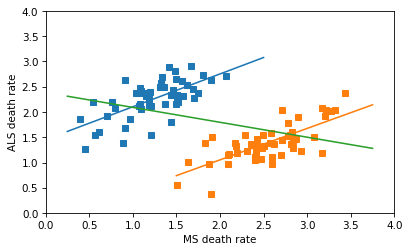

In [8]:
plt.plot(male_ms, male_als, 's', label='male')
plt.plot(male_xs, male_ys, color="C0")
plt.plot(female_ms, female_als, 's', label='female')
plt.plot(female_xs, female_ys, color="C1")
plt.plot(combined_xs, combined_ys, color="C2", label='combined')

def decorate():
    plt.xlabel('MS death rate')
    plt.ylabel('ALS death rate')
    plt.xlim([0, 4])
    plt.ylim([0, 4])
    
decorate()

The line for the combined data has a non-negligible negative slope, and the correlation is about -0.4 -- so this is not the line that appears in the original figure, which has a very small correlation.
So, I don't know where that line came from.

In any case, the correct way to combine the data is not to plot a line through 102 points in the scatterplot, but to fit a line to the combined death rates in the 51 states.
Assuming that the gender ratios in the states are close to 50/50, the combined rates are just the means of the male and female rates, which we can compute like this.

In [9]:
all_ms = (male_ms + female_ms) / 2
all_als = (male_als + female_als) / 2
all_result = linregress(all_ms, all_als)

all_xs = np.linspace(0.75, 3.75)
all_ys = all_result.intercept + all_result.slope * all_xs
all_result.rvalue

0.6675995026201546

The correlation in the combined data is about the same as what it is in the groups.

And here's what the correctly combined data look like.

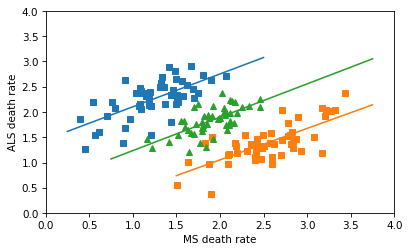

In [10]:
plt.plot(male_ms, male_als, 's', label='male')
plt.plot(male_xs, male_ys, color="C0")
plt.plot(female_ms, female_als, 's', label='female')
plt.plot(female_xs, female_ys, color="C1")

plt.plot(all_ms, all_als, '^', label='all')
plt.plot(all_xs, all_ys, color="C2")

decorate()

So there's no Simpson's paradox here -- there's a positive correlation among the subgroups, and there's a positive correlation when we combine them.
I love a good Simpson's paradox, but this isn't one of them.

On a quick skim, I think the rest of the paper is also likely to be nonsensical, but I'll leave that for other people to debunk.

Allen Downey
[MIT License](https://mit-license.org/)